Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--op-ratio', '0.01', '--txn-count', '16', '--delta-count', '6', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.01
Analytical ratio: 0.2
Number of transactions (max Timestamp value): 16
Number of delta_scan transactions: 6

-----------------------------------------------------------------------

txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 300000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 3000
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     Update, Update count: 3000
idx:   4, tx_id:   4, tx_ts:   4, tx_type:     Update, Update count: 3000
idx:   5, tx_id:   5, tx_ts:   5, tx_type:     Updat

,idx,tx_id,tx_type,repair_type,table_type,duration_ms,count,read_ts,from_ts,to_ts
0,0,0,InitLoad,No Repair,naive,72.392355,300000.0,NaN,NaN,NaN
1,0,0,InitLoad,Read Repair,naive,73.360654,300000.0,NaN,NaN,NaN
2,0,0,InitLoad,Write Repair,naive,70.610142,300000.0,NaN,NaN,NaN
3,1,1,MarkTs,No Repair,naive,105.553229,NaN,1.0,NaN,NaN
4,1,1,MarkTs,Read Repair,naive,105.143726,NaN,1.0,NaN,NaN
5,1,1,MarkTs,Write Repair,naive,105.653093,NaN,1.0,NaN,NaN
6,2,2,Update,No Repair,naive,1.270702,3000.0,NaN,NaN,NaN
7,2,2,Update,Read Repair,naive,1.276942,3000.0,NaN,NaN,NaN
8,2,2,Update,Write Repair,naive,1.270648,3000.0,NaN,NaN,NaN
9,3,3,Update,No Repair,naive,1.188741,3000.0,NaN,NaN,NaN


duration_max: 310.749362


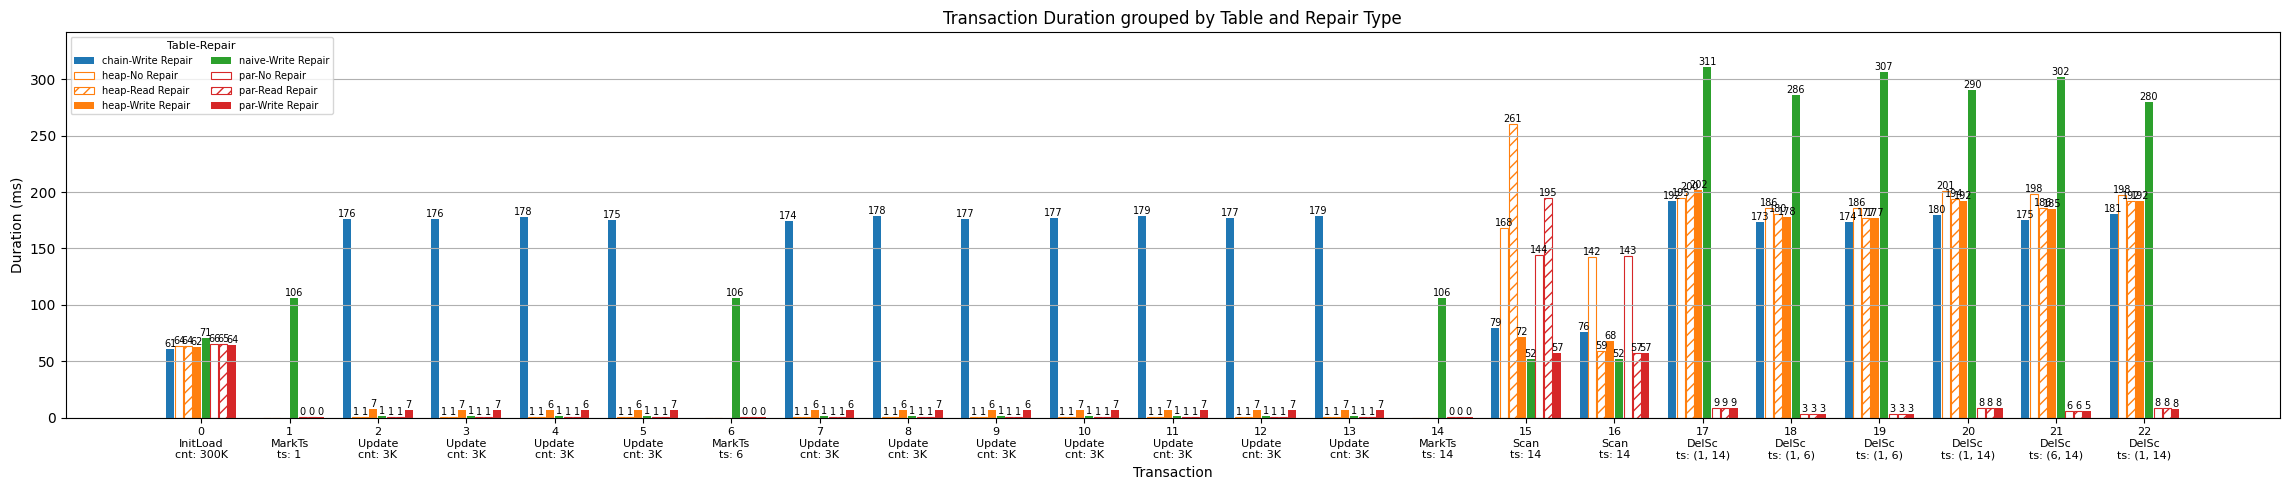

In [32]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

BASE_ARGS = [
    "--op-ratio", "0.01",
    "--txn-count", "16",
    "--delta-count", "6",
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = ["naive", "heap", "par", "chain"]
def parse_result(log_text, table_type):
    data = []
    repair_type = None
    no_repair_run_count = 0

    for line in log_text.splitlines():
        line = line.strip()

        if line.startswith("No Repair"):
            repair_type = "No Repair"
            no_repair_run_count += 1
            continue
        elif line.startswith("Read Repair"):
            repair_type = "Read Repair"
            continue
        elif line.startswith("Write Repair"):
            repair_type = "Write Repair"
            continue
        
        match = re.match(r'\[(.*?)\]\s+idx:\s+(\d+),\s+tx_id:\s+(\d+),\s+tx_type:\s+(\w+),\s+duration:\s+([0-9\.]+)(ms|s|µs|ns),(.*)', line)
        if match and repair_type:
            if repair_type == "No Repair" and no_repair_run_count == 1:
                continue
            
            _, idx, tx_id, tx_type, duration_value, duration_unit, rest = match.groups()

            duration_value = float(duration_value)
            if duration_unit == 's':
                duration_ms = duration_value * 1000
            elif duration_unit == 'ms':
                duration_ms = duration_value
            elif duration_unit == 'µs':
                duration_ms = duration_value / 1000
            elif duration_unit == 'ns':
                duration_ms = 0.
            else:
                raise ValueError(f"Unknown time unit: {duration_unit}")
            
            count = None
            read_ts = None
            from_ts = None
            to_ts = None
            if 'InitialLoad count' in rest or 'Update count' in rest:
                count_match = re.search(r'count:\s*(\d+)', rest)
                if count_match:
                    count = int(count_match.group(1))
            if 'to' in rest and 'from' in rest:
                from_match = re.search(r'from read_ts:\s*(\d+)', rest)
                if from_match:
                    from_ts = int(from_match.group(1))
                
                to_match = re.search(r'to tx_ts:\s*(\d+)', rest)
                if to_match:
                    to_ts = int(to_match.group(1))
            elif 'read_ts' in rest:
                read_ts_match = re.search(r'read_ts:\s*(\d+)', rest)
                if read_ts_match:
                    read_ts = int(read_ts_match.group(1))
            data.append({
                'table_type': table_type,
                'repair_type': repair_type,
                'idx': int(idx),
                'tx_id': int(tx_id),
                'tx_type': tx_type,
                'duration_ms': duration_ms,
                'count': count,
                'read_ts': read_ts,
                'from_ts': from_ts,
                'to_ts': to_ts
            })
    return pd.DataFrame(data)
def run_and_collect(bin_path, table_types, base_args):
    all_dfs = []
    for table_type in table_types:
        print(f"Running for table_type={table_type} with {REPEAT} repeats...")
        dfs = []
        for trail in range(REPEAT):
            print(f"   - Trail {trail + 1}/{REPEAT}")

            args = [str(bin_path)] + base_args + ["--table-type", table_type]
            print(args)

            result = subprocess.run(
                args, 
                stdout=subprocess.PIPE,
                stderr = subprocess.PIPE,
                text=True,
            )

            print(result.stdout)
            df = parse_result(result.stdout, table_type)
            dfs.append(df)
        if dfs:
            # Concatenate all repeated runs
            df_all = pd.concat(dfs, ignore_index=True)
            # Group by (idx, tx_id, tx_type, repair_type, table_type) and average duration_ms
            df_avg = (
                df_all
                .groupby(['idx', 'tx_id', 'tx_type', 'repair_type', 'table_type'], as_index=False)
                .agg({
                    'duration_ms': 'mean',
                    'count': 'first',
                    'read_ts': 'first',
                    'from_ts': 'first',
                    'to_ts': 'first'
                })
            )

            all_dfs.append(df_avg)
    if all_dfs:
        final_df = pd.concat(all_dfs, ignore_index=True)
        return final_df
    else:
        return pd.DataFrame()


def prepare_plot_data(df):
    prop_cycler = plt.rcParams['axes.prop_cycle']
    colors = prop_cycler.by_key()['color']

    table_types = sorted(df['table_type'].unique())
    color_map = {table_type: colors[i % len(colors)] for i, table_type in enumerate(table_types)}

    repair_hatches = {
        "Write Repair": "",
        "Read Repair": "///",
        "No Repair": "",
    }
    repair_types = ["No Repair", "Read Repair", "Write Repair"]

    unique_idx = sorted(df['idx'].unique())

    x_labels = []
    for idx in unique_idx:
        row = df[df['idx'] == idx].iloc[0]
        optional = ""
        if row['tx_type'] in ["InitLoad", "Update"] and pd.notnull(row['count']):
            count = int(row['count'])
            if count >= 1_000_000:
                value = count / 1_000_000
                count_str = f"{value:.1f}".rstrip('0').rstrip('.') + "M"
            elif count >= 1_000:
                value = count / 1_000
                count_str = f"{value:.1f}".rstrip('0').rstrip('.') + "K"
            else:
                count_str = str(count)
            optional = f"cnt: {count_str}"
        elif row['tx_type'] in ["Scan", "MarkTs"] and pd.notnull(row['read_ts']):
            optional = f"ts: {int(row['read_ts'])}"
        elif row['tx_type'] in ["DeltaScan"] and pd.notnull(row['from_ts']) and pd.notnull(row['to_ts']):
            optional = f"ts: ({int(row['from_ts'])}, {int(row['to_ts'])})"
        tx_type = row['tx_type']
        if row['tx_type'] in ["DeltaScan"]:
            tx_type = "DelSc"
        label = f"{idx}\n{tx_type}\n{optional}"
        x_labels.append(label)

    return color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels

def prepare_bar_style(repair_type, table_type, color_map, repair_hatches):
    if repair_type == "Write Repair":
        return {
            'facecolor': color_map[table_type],
            'edgecolor': color_map[table_type],
            'hatch': '',
            'linewidth': 0
        }
    else:
        return {
            'facecolor': 'white',
            'edgecolor': color_map[table_type],
            'hatch': repair_hatches.get(repair_type, ''),
            'linewidth': 0.8
        }
def draw_bar_labels(ax, x_positions, heights, font_size=7):
    for x, y in zip(x_positions, heights):
        if y > 0:  
            ax.text(
                x, 
                y, 
                f"{y:.0f}", 
                ha='center', 
                va='bottom', 
                fontsize=font_size
            )
def plot_all(df):
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels = prepare_plot_data(df)

    fig, ax = plt.subplots(figsize=(max(8, len(unique_idx) * 1.0), 5))

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "naive"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    num_bars_per_group = len(groups)
    group_width = 0.8
    bar_width = group_width / num_bars_per_group

    idx_to_pos = {idx: pos for pos, idx in enumerate(unique_idx)}

    duration_max = 0.0
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        x_positions = []
        durations = []

        for idx in unique_idx:
            x_pos = idx_to_pos[idx] + (i - num_bars_per_group/2) * bar_width + bar_width/2
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            x_positions.append(x_pos)
            durations.append(duration)

        style = prepare_bar_style(repair_type, table_type, color_map, repair_hatches)

        ax.bar(
            x_positions,
            durations,
            width=bar_width * 0.9,
            label=f"{table_type}-{repair_type}",
            **style
        )
        duration_max = max(duration_max, max(durations))
        draw_bar_labels(ax, x_positions, durations)

  
    print(f"duration_max: {duration_max}")
    max_y = duration_max * 1.1
    ax.set_ylim(0, max_y)

    ax.set_xticks(range(len(unique_idx)))
    ax.set_xticklabels(x_labels, rotation=0, fontsize=8, ha='center')

    ax.set_xlabel('Transaction')
    ax.set_ylabel('Duration (ms)')
    ax.set_title(f'Transaction Duration grouped by Table and Repair Type')

    plt.grid(True, axis='y')

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title="Table-Repair", fontsize=7, title_fontsize=8, ncol=2)

    plt.tight_layout()
    plt.show()
df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
display(df)
plot_all(df)



# DELTA TRADEOFF

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--txn-count', '16', '--delta-count', '6', '--op-ratio', '0.01', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.01
Analytical ratio: 0.2
Number of transactions (max Timestamp value): 16
Number of delta_scan transactions: 6

-----------------------------------------------------------------------

txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 300000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 3000
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     Update, Update count: 3000
idx:   4, tx_id:   4, tx_ts:   4, tx_type:     Update, Update count: 3000
idx:   5, tx_id:   5, tx_ts:   5, tx_type:     Updat

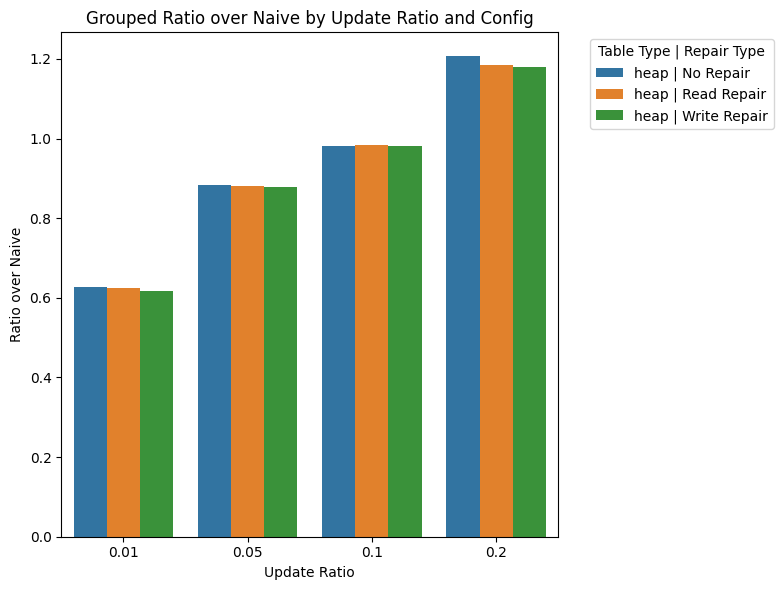

In [ ]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

BASE_ARGS = [
    "--txn-count", "16",
    "--delta-count", "6",
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = ["naive", "heap"]
UPDATE_RATIOS = ["0.01", "0.05", "0.1", "0.2"]
def parse_result(log_text, table_type):
    data = []
    repair_type = None
    no_repair_run_count = 0

    for line in log_text.splitlines():
        line = line.strip()

        if line.startswith("No Repair"):
            repair_type = "No Repair"
            no_repair_run_count += 1
            continue
        elif line.startswith("Read Repair"):
            repair_type = "Read Repair"
            continue
        elif line.startswith("Write Repair"):
            repair_type = "Write Repair"
            continue
        
        match = re.match(r'\[(.*?)\]\s+idx:\s+(\d+),\s+tx_id:\s+(\d+),\s+tx_type:\s+(\w+),\s+duration:\s+([0-9\.]+)(ms|s|µs|ns),(.*)', line)
        if match and repair_type:
            if repair_type == "No Repair" and no_repair_run_count == 1:
                continue
            
            _, idx, tx_id, tx_type, duration_value, duration_unit, rest = match.groups()

            duration_value = float(duration_value)
            if duration_unit == 's':
                duration_ms = duration_value * 1000
            elif duration_unit == 'ms':
                duration_ms = duration_value
            elif duration_unit == 'µs':
                duration_ms = duration_value / 1000
            elif duration_unit == 'ns':
                duration_ms = 0.
            else:
                raise ValueError(f"Unknown time unit: {duration_unit}")
            
            count = None
            read_ts = None
            from_ts = None
            to_ts = None
            if 'InitialLoad count' in rest or 'Update count' in rest:
                count_match = re.search(r'count:\s*(\d+)', rest)
                if count_match:
                    count = int(count_match.group(1))
            if 'to' in rest and 'from' in rest:
                from_match = re.search(r'from read_ts:\s*(\d+)', rest)
                if from_match:
                    from_ts = int(from_match.group(1))
                
                to_match = re.search(r'to tx_ts:\s*(\d+)', rest)
                if to_match:
                    to_ts = int(to_match.group(1))
            elif 'read_ts' in rest:
                read_ts_match = re.search(r'read_ts:\s*(\d+)', rest)
                if read_ts_match:
                    read_ts = int(read_ts_match.group(1))
            data.append({
                'table_type': table_type,
                'repair_type': repair_type,
                'idx': int(idx),
                'tx_id': int(tx_id),
                'tx_type': tx_type,
                'duration_ms': duration_ms,
                'count': count,
                'read_ts': read_ts,
                'from_ts': from_ts,
                'to_ts': to_ts
            })
    return pd.DataFrame(data)
def run_and_collect(bin_path, table_types, base_args):
    all_dfs = []
    for table_type in table_types:
        print(f"Running for table_type={table_type} with {REPEAT} repeats...")
        dfs = []
        for trail in range(REPEAT):
            print(f"   - Trail {trail + 1}/{REPEAT}")

            args = [str(bin_path)] + base_args + ["--table-type", table_type]
            print(args)

            result = subprocess.run(
                args, 
                stdout=subprocess.PIPE,
                stderr = subprocess.PIPE,
                text=True,
            )

            print(result.stdout)
            df = parse_result(result.stdout, table_type)
            dfs.append(df)
        if dfs:
            # Concatenate all repeated runs
            df_all = pd.concat(dfs, ignore_index=True)
            # Group by (idx, tx_id, tx_type, repair_type, table_type) and average duration_ms
            df_avg = (
                df_all
                .groupby(['idx', 'tx_id', 'tx_type', 'repair_type', 'table_type'], as_index=False)
                .agg({
                    'duration_ms': 'mean',
                    'count': 'first',
                    'read_ts': 'first',
                    'from_ts': 'first',
                    'to_ts': 'first'
                })
            )

            all_dfs.append(df_avg)
    if all_dfs:
        final_df = pd.concat(all_dfs, ignore_index=True)
        return final_df
    else:
        return pd.DataFrame()


def prepare_plot_data(df):
    prop_cycler = plt.rcParams['axes.prop_cycle']
    colors = prop_cycler.by_key()['color']

    table_types = sorted(df['table_type'].unique())
    color_map = {table_type: colors[i % len(colors)] for i, table_type in enumerate(table_types)}

    repair_hatches = {
        "Write Repair": "",
        "Read Repair": "///",
        "No Repair": "",
    }
    repair_types = ["No Repair", "Read Repair", "Write Repair"]

    unique_idx = sorted(df['idx'].unique())

    x_labels = []
    for idx in unique_idx:
        row = df[df['idx'] == idx].iloc[0]
        optional = ""
        if row['tx_type'] in ["InitLoad", "Update"] and pd.notnull(row['count']):
            count = int(row['count'])
            if count >= 1_000_000:
                value = count / 1_000_000
                count_str = f"{value:.1f}".rstrip('0').rstrip('.') + "M"
            elif count >= 1_000:
                value = count / 1_000
                count_str = f"{value:.1f}".rstrip('0').rstrip('.') + "K"
            else:
                count_str = str(count)
            optional = f"cnt: {count_str}"
        elif row['tx_type'] in ["Scan", "MarkTs"] and pd.notnull(row['read_ts']):
            optional = f"ts: {int(row['read_ts'])}"
        elif row['tx_type'] in ["DeltaScan"] and pd.notnull(row['from_ts']) and pd.notnull(row['to_ts']):
            optional = f"ts: ({int(row['from_ts'])}, {int(row['to_ts'])})"
        tx_type = row['tx_type']
        if row['tx_type'] in ["DeltaScan"]:
            tx_type = "DelSc"
        label = f"{idx}\n{tx_type}\n{optional}"
        x_labels.append(label)

    return color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels

def prepare_bar_style(repair_type, table_type, color_map, repair_hatches):
    if repair_type == "Write Repair":
        return {
            'facecolor': color_map[table_type],
            'edgecolor': color_map[table_type],
            'hatch': '',
            'linewidth': 0
        }
    else:
        return {
            'facecolor': 'white',
            'edgecolor': color_map[table_type],
            'hatch': repair_hatches.get(repair_type, ''),
            'linewidth': 0.8
        }
def draw_bar_labels(ax, x_positions, heights, font_size=7):
    for x, y in zip(x_positions, heights):
        if y > 0:  
            ax.text(
                x, 
                y, 
                f"{y:.0f}", 
                ha='center', 
                va='bottom', 
                fontsize=font_size
            )
def plot_all(df):
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels = prepare_plot_data(df)

    fig, ax = plt.subplots(figsize=(max(8, len(unique_idx) * 1.0), 5))

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "naive"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    num_bars_per_group = len(groups)
    group_width = 0.8
    bar_width = group_width / num_bars_per_group

    idx_to_pos = {idx: pos for pos, idx in enumerate(unique_idx)}

    duration_max = 0.0
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        x_positions = []
        durations = []

        for idx in unique_idx:
            x_pos = idx_to_pos[idx] + (i - num_bars_per_group/2) * bar_width + bar_width/2
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            x_positions.append(x_pos)
            durations.append(duration)

        style = prepare_bar_style(repair_type, table_type, color_map, repair_hatches)

        ax.bar(
            x_positions,
            durations,
            width=bar_width * 0.9,
            label=f"{table_type}-{repair_type}",
            **style
        )
        duration_max = max(duration_max, max(durations))
        draw_bar_labels(ax, x_positions, durations)

  
    print(f"duration_max: {duration_max}")
    max_y = duration_max * 1.1
    ax.set_ylim(0, max_y)

    ax.set_xticks(range(len(unique_idx)))
    ax.set_xticklabels(x_labels, rotation=0, fontsize=8, ha='center')

    ax.set_xlabel('Transaction')
    ax.set_ylabel('Duration (ms)')
    ax.set_title(f'Transaction Duration grouped by Table and Repair Type')

    plt.grid(True, axis='y')

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title="Table-Repair", fontsize=7, title_fontsize=8, ncol=2)

    plt.tight_layout()
    plt.show()


def get_avg(df):
    color_map, repair_hatches, repair_types, table_types, _, _ = prepare_plot_data(df)
    tx_type_groups = ["DeltaScan"]
    groups = []
    for table_type in table_types:
        if table_type in ['naive', 'chain']:
            groups.append((table_type, 'Write Repair'))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))
    
    durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]
        
        # DeltaScan only average
        scan_vals = df_group[df_group['tx_type'] == "DeltaScan"]['duration_ms'].values
        avg_delta_scan = scan_vals.mean() if len(scan_vals) > 0 else 0
        durations.append((table_type, repair_type, avg_delta_scan)) # table_type, repair_type, avg_duration

    return durations

# get ratio over base_type
def get_ratio(avg, base_type, update_ratio):
    result = []
    ratio_col_name = f'ratio_over_{base_type}'
    base = None
    for (table_type, repair_type, avg_dur) in avg:
        if table_type in [base_type]:
            base = avg_dur
    
    for (table_type, repair_type, avg_dur) in avg:
        if table_type not in [base_type]:
            result.append({"update_ratio": update_ratio, "table_type": table_type, "repair_type": repair_type, ratio_col_name: avg_dur / base})

    df_res = pd.DataFrame(result)
    return df_res

df_ratio = pd.DataFrame()
for update_ratio in UPDATE_RATIOS:
    NEW_ARGS = BASE_ARGS.copy()
    NEW_ARGS += ["--op-ratio", update_ratio]
    
    df = run_and_collect(BIN, TABLE_TYPES, NEW_ARGS)

    # Display the resulting DataFrame
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', None)
    # display(df)
    df_avg = get_avg(df)
    ratio = get_ratio(df_avg, 'naive', update_ratio)
    df_ratio = pd.concat([df_ratio, ratio], ignore_index=True)
df_ratio['idx'] = range(len(df_ratio))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
def draw_plot(df):

    # Optional: combine table_type and repair_type into a single label
    df["config"] = df["table_type"] + " | " + df["repair_type"]

    # Plot grouped barplot
    plt.figure(figsize=(8, 6))
    sns.barplot(data=df, x="update_ratio", y="ratio_over_naive", hue="config")

    plt.ylabel("Ratio: Naive over Heap")
    plt.xlabel("Update Ratio")
    plt.title("Grouped Ratio over Naive by Update Ratio and Config")
    plt.legend(title="Table Type | Repair Type", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

draw_plot(df_ratio)
